<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5>
سوال چهار آمار توصیفی
</font>
</p>

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv("Divar.csv")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\1381234337.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Divar.csv")


In [53]:
#حذف اگهی‌هایی که قیمت فروش ندارن
sale_df = df[df["price_value"].notna()].copy()
#حذف اگهی‌هایی که قیمت صقر یا منفی دارن
sale_df = sale_df[sale_df["price_value"] > 0]

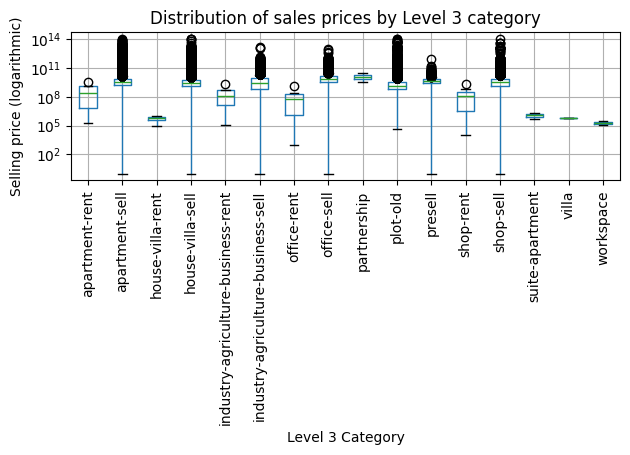

In [54]:
#رسم نمودار 
sale_df.boxplot(column="price_value", by="cat3_slug", rot=90)

#تبدیل ستون عمودی به مقیاس لگاریتمی
plt.yscale("log")
plt.title("Distribution of sales prices by Level 3 category")
plt.suptitle("")   
plt.xlabel("Level 3 Category")
plt.ylabel("Selling price (logarithmic)")

plt.tight_layout()
plt.show()

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
نمودار جعبه‌ای توزیع قیمت فروش دسته بندی‌های مختلف سطح سه رو نمایش میده و چون خیلی دامنه قیمت ها گسترده بود محور عمودی که بیانگر sale price هست رو به حالت لگاریتمی نمایش دادم 
<br>
برای تخلیل این نمودار میتونیم بگیم که میانه قیمت فروش توی دسته‌بندی های مختلف یکسان نیستش و بعضی از دسته‌ها قیمت بالاتر یا پایین تری دارن و توی خیلی از دسته‌ها داده‌های پرت دیده میشه و این موضوع میتونه نشون دهنده این باشه که تو هر دسته تعدادی ملک با قیمت زیاد یا خیلی کم وجود داره. 
همانطور که توی نمودار میبینین اندازه جعبه‌ها توی یه سری از دسته‌ها بزرگتره که بیانگر پراکندگی بیشتر قیمت توی اون دسته هست و در کل این نمودار نشون میده که فیمت فروش و میانگین و میانه و میزان پراکندگی و تعداد داده‌های پرت توی دسته‌ها تفاوت داره.

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5>
سوال هفت آمار توصیفی
</font>
</p>

In [55]:
#تبدیل ستون تاریخ به یه حالتی که بشه سال و اینا رو تشخیص بده
df["created_at_month"] = pd.to_datetime(df["created_at_month"])
#سال رو از تاریخ بیرون میاره
df["year"] = df["created_at_month"].dt.year
# اگهای‌هایی که قیمت فروش دارن رو توی این متغییر ذخیره میکنه
price_df = df[df["price_value"].notna()].copy()

In [56]:
# محاسبه قیمت قروش تو هر سال
average_price = (price_df.groupby("year")["price_value"].mean().reset_index())

In [57]:
# ذخیره اطلاعات شاخص تورم توی هر سال از 1400 تا 1403
cpi = {
    2021: 437.02,
    2022: 640.225,
    2023: 974.750,
    2024: 1324 }

In [58]:
# اضافه کردن شاخص هر سال به جدول
average_price["cpi"] = average_price["year"].map(cpi)
# شاخص مبنا رو ذخیره میکنیم و چون معمولا سال اخر رو مبنا قرار میدن منم همین سال اخر رو مبنا قرار میدم
base_cpi = cpi[2024]

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=4>
قیمت حقیقی = قیمت اسمی * شاخص قیمت سال مبنا cpi/ شاخص قیمت سال مورد نظر cpi
</font>
</p>

In [59]:
# محاسبه قیمت حقیقی
average_price["real_price"] = average_price["price_value"] * base_cpi / average_price["cpi"]
average_price

,year,price_value,cpi,real_price
0,2021,1.435000e+10,437.020,4.347490e+10
1,2022,1.010927e+10,640.225,2.090621e+10
2,2023,8.248310e+09,974.750,1.120365e+10
3,2024,1.737756e+10,1324.000,1.737756e+10
4,2025,2.138301e+10,NaN,NaN


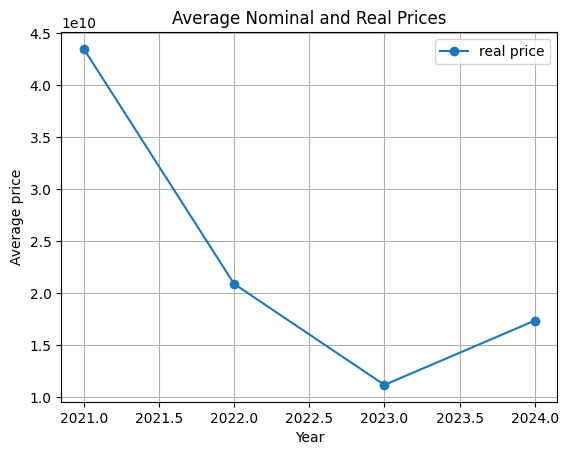

In [60]:
# رسم نمودار
plt.plot(average_price["year"], average_price["real_price"], marker = "o", label="real price")

plt.xlabel("Year")
plt.ylabel("Average price")
plt.title("Average Nominal and Real Prices")
plt.legend()
plt.grid(True)
plt.show()

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
یه ایرادی که دیده میشه در نمودار بالا اینه که تعداد آگهی‌ها توی سالهای مختلف نامتوازنن و در واقع این تحلیل فقط بر اساس داده‌های توی df هست و نمیتونه بیانگر کل بازار مسکن در هر سال باشه اگر به اطلاعات زیر توجه کنیم میبینیم که تعداد آگهی‌ها در هر سال باهم برابر نیستن
<br>
اگر بخوایم یه تحلیل کلی بر اساس نمودار داشته باشیم میتونیم بگیم که: نمودار قیمت حقیقی نشون میده که بیشترین میانگین قیمت حقیقی برای سال 2021 یعنی تقریبا برای 1400 هست و بعد از آن در سالهای 2022 و 2023 روند نزولی و در 2024 که تقریبا بیانگر 1403 هست افزایش دیده میشه 
<br> 
این نتیجه میتونه بیانگر این باشه که با حذف تورم افزایش قیمت اسمی لزوما به معنی این نیست که ارزش واقعی املاک هم افزایش پیدا میکنه و ممکنه که ارزش واقعی توی یه سری از سالها کاهش پیدا کنه ولی خب در کل به تعداد اگهی‌ها توی هر سال هم باید توجه داشت 
</font>
</p>

In [61]:
# تعداد اگهی‌ها تو سال‌های 1400 تا 1403
price_df["year"].value_counts()

year
2024    566241
2023      1146
2025       931
2022        26
2021         2
Name: count, dtype: int64